### Follow-up Coding Exercise: Advanced Decoding Strategies for Speech Language Models

This script extends the lightweight SpeechLM pre-training by implementing and comparing multiple advanced decoding strategies for sequence generation. It demonstrates how different sampling techniques affect output diversity and quality in speech token prediction.

Key Libraries Used:

    torch: Neural network operations and probability functions

    torch.nn.functional: Softmax and sampling utilities

    numpy: Random token generation

    matplotlib: Training loss visualization

    torch.utils.data: Efficient data handling

Code Logic and Flow

High-Level Overview
The pipeline builds upon the pre-trained lightweight SpeechLM to implement and test various decoding strategies. It systematically compares greedy, temperature, top-k, and top-p sampling approaches using a common starting token, demonstrating their impact on generation diversity and quality.

Visual Flowchart

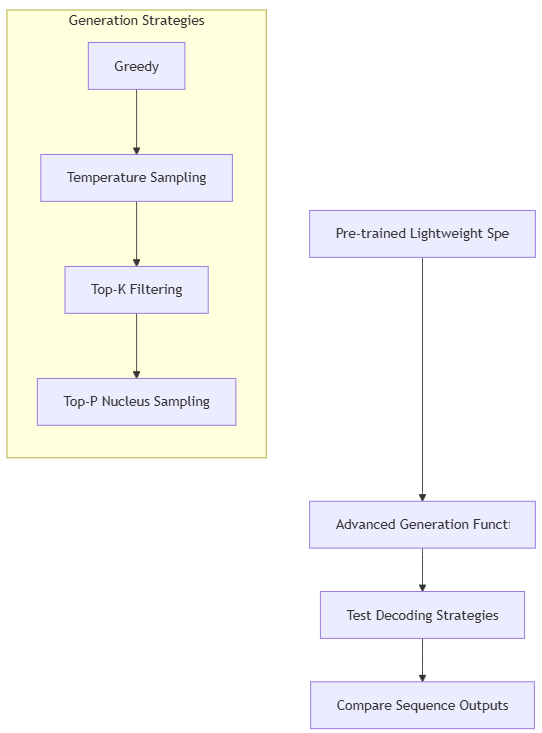

Step-by-Step Code Breakdown

    Lightweight Model Foundation

        Retains previous script's:

            Compact architecture (1 layer, 32D embeddings)

            30-epoch pre-training

            200-sample synthetic dataset

        Loss visualization: "lightweight_pretrain_loss_adv_gen.png"

    Advanced Generation Function

        Core Parameters:

            strategy: Greedy/temperature/top-k/top-p

            temperature: Controls randomness (0.7-1.5)

            top_k: Limits sampling to k most probable tokens

            top_p: Nucleus sampling probability threshold

        Key Features:

            Sequence length validation

            Probability distribution handling:

                Temperature scaling

                Top-k token filtering

                Top-p cumulative distribution

            Edge case handling:

                Zero-probability fallbacks

                Invalid temperature correction

    Decoding Strategy Suite

        Greedy: Always selects highest-probability token

        Temperature Sampling:

            Low temp (0.7): More deterministic

            High temp (1.5): More diverse

        Top-K Sampling:

            k=1: Equivalent to greedy

            k=3: Moderate diversity

            k>vocab_size: All tokens considered

        Top-P (Nucleus) Sampling:

            p=0.9: Broad token set

            p=0.5: Focused selection

            p=0.05: Highly constrained

    Comparative Testing

        Common Start Token: Random non-mask token

        Test Cases: 10 distinct strategies

        Output Analysis: Printed sequences for direct comparison

Connecting to Lecture Concepts

    Decoding Strategy Theory

        Implements Module 6.2's "Controlled Text Generation"

        Demonstrates Lecture 7.3's diversity-quality tradeoff

    Temperature Effects

        Lower values → more predictable outputs

        Higher values → increased creativity

    Top-K Sampling

        Balances diversity and quality (Lecture 6.4)

        k=1 equivalent to greedy decoding

    Nucleus Sampling

        Dynamic token selection (Top-P)

        Addresses Lecture 7.1's "tail token problem"

    Real-World Applications

        Used in:

            ChatGPT (temperature sampling)

            GPT-3 (top-p sampling)

            Voice assistant response generation

    Educational Insights

        Shows how decoding strategies affect:

            Output coherence

            Repetition avoidance

            Creative variance

    Practical Considerations

        Strategy selection depends on:

            Application requirements

            Desired creativity level

            Tolerance for errors

    Research Connections

        Compared in:

            Holtzman et al. (2020) "The Curious Case of Neural Text Degeneration"

            Fan et al. (2018) "Hierarchical Neural Story Generation"

    Forward-Looking Concepts

        Extension to:

            Beam search optimization

            Typicality sampling

            Contrastive search

        Integration with:

            Length normalization

            Repetition penalties

    Diagnostic Value

        Enables analysis of:

            Model confidence calibration

            Vocabulary utilization patterns

            Prediction distribution characteristics

Using PyTorch version: 2.7.0+cpu
Using device: cpu
Shape of synthetic data: torch.Size([200, 8])

Starting Pre-training with 30 epochs...


C:\Users\vinit\anaconda3\envs\speechlm-rough\Lib\site-packages\torch\nn\modules\transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Pre-Training Epoch [10/30], Average Loss: 2.2778
Pre-Training Epoch [20/30], Average Loss: 2.2421
Pre-Training Epoch [30/30], Average Loss: 2.2168
Pre-training finished.


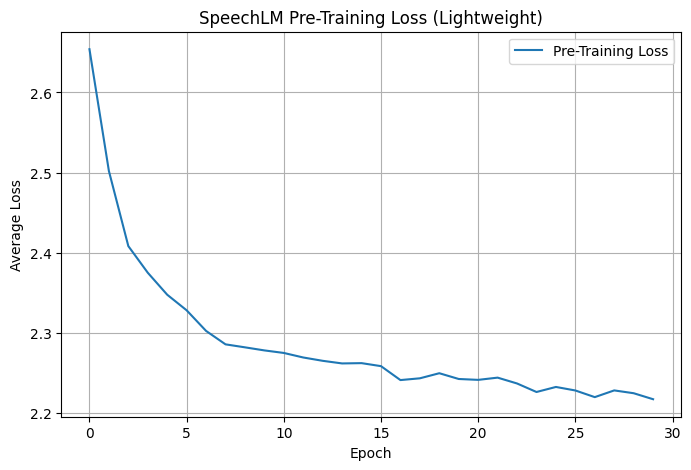


Loss plot saved as lightweight_pretrain_loss_adv_gen.png

--- Testing Advanced Generation Strategies ---
Common start token(s): [2]
Max generation length: 8

Generating with: Greedy
  Output: [np.int64(2), 1, 2, 0, 0, 4, 3, 0]

Generating with: Temp=0.7 Sample
  Output: [np.int64(2), 3, 8, 6, 3, 7, 4, 1]

Generating with: Temp=1.0 Sample (Default)
  Output: [np.int64(2), 8, 1, 9, 8, 7, 8, 6]

Generating with: Temp=1.5 Sample
  Output: [np.int64(2), 5, 5, 4, 5, 7, 7, 1]

Generating with: Top-K (k=1, Temp=1.0)
  Output: [np.int64(2), 1, 2, 0, 0, 4, 3, 0]

Generating with: Top-K (k=3, Temp=1.0)
  Output: [np.int64(2), 1, 9, 0, 0, 8, 0, 2]

Generating with: Top-K (k=5, Temp=1.0)
  Output: [np.int64(2), 0, 9, 9, 6, 4, 6, 4]

Generating with: Top-P (p=0.5, Temp=1.0)
  Output: [np.int64(2), 0, 7, 1, 0, 3, 5, 4]

Generating with: Top-P (p=0.9, Temp=1.0)
  Output: [np.int64(2), 1, 9, 0, 6, 4, 4, 6]

Generating with: Top-P (p=0.05, Temp=1.0)
  Output: [np.int64(2), 1, 2, 0, 0, 4, 3, 0]

Advance

In [7]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F # For softmax
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader

print(f"Using PyTorch version: {torch.__version__}")

# --- Parameters for a Lightweight Model (same as previous script) ---
vocab_size = 10
seq_length = 8
d_model = 32
n_layers = 1
n_heads = 2
d_ff = 64
dropout_rate = 0.1

# --- Pre-training Parameters (same as previous script) ---
n_epochs_pretrain = 30 # Kept it at 30 for demonstration, can be reduced for speed
batch_size = 16
learning_rate = 0.001
num_synthetic_samples = 200
mask_percentage = 0.15

# Determine device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# --- Step 1: Generate Lightweight Synthetic Speech Token Data (same) ---
np.random.seed(42)
synthetic_data_np = np.random.randint(0, vocab_size, size=(num_synthetic_samples, seq_length))
synthetic_data_torch = torch.tensor(synthetic_data_np, dtype=torch.long)
dataset = TensorDataset(synthetic_data_torch)
pretrain_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
print(f"Shape of synthetic data: {synthetic_data_torch.shape}")


# --- Step 2: Define a Simple Transformer Model (SpeechLM - same) ---
class SpeechLM(nn.Module):
    def __init__(self, vocab_size, d_model, n_layers, n_heads, d_ff, max_seq_len, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoding = nn.Parameter(torch.randn(1, max_seq_len, d_model))
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=d_ff,
            dropout=dropout, batch_first=True, norm_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.fc_out = nn.Linear(d_model, vocab_size)
        self.max_seq_len = max_seq_len

    def forward(self, src_tokens):
        batch_size, seq_len_input = src_tokens.shape
        if seq_len_input > self.max_seq_len:
            raise ValueError(f"Input sequence length ({seq_len_input}) exceeds model's max_seq_len ({self.max_seq_len})")
        embedded_tokens = self.embedding(src_tokens)
        positioned_input = embedded_tokens + self.pos_encoding[:, :seq_len_input, :]
        causal_mask = torch.triu(torch.ones(seq_len_input, seq_len_input, device=src_tokens.device) * float('-inf'), diagonal=1)
        transformer_output = self.transformer_encoder(positioned_input, mask=causal_mask)
        logits = self.fc_out(transformer_output)
        return logits

# --- Step 3: Pre-Training (Masked Token Prediction style - same) ---
model = SpeechLM(
    vocab_size=vocab_size, d_model=d_model, n_layers=n_layers, n_heads=n_heads,
    d_ff=d_ff, max_seq_len=seq_length, dropout=dropout_rate
).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.CrossEntropyLoss()

print(f"\nStarting Pre-training with {n_epochs_pretrain} epochs...")
pretrain_losses = []
for epoch in range(n_epochs_pretrain):
    model.train()
    epoch_loss = 0
    num_batches = 0
    for (batch_sequences,) in pretrain_loader:
        batch_sequences = batch_sequences.to(device)
        optimizer.zero_grad()
        original_input_sequences = batch_sequences[:, :-1]
        target_sequences = batch_sequences[:, 1:]
        masked_model_input = original_input_sequences.clone()
        prob_mask = torch.rand(masked_model_input.shape, device=device) < mask_percentage
        masked_model_input[prob_mask] = vocab_size - 1
        output_logits = model(masked_model_input)
        loss = criterion(output_logits.reshape(-1, vocab_size), target_sequences.reshape(-1))
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        num_batches +=1
    avg_epoch_loss = epoch_loss / num_batches
    pretrain_losses.append(avg_epoch_loss)
    if (epoch+1) % 10 == 0: # Print less frequently
        print(f"Pre-Training Epoch [{epoch+1}/{n_epochs_pretrain}], Average Loss: {avg_epoch_loss:.4f}")
print("Pre-training finished.")

# --- Step 4: Plot Pre-training Losses (same) ---
plt.figure(figsize=(8, 5))
plt.plot(pretrain_losses, label="Pre-Training Loss")
plt.title("SpeechLM Pre-Training Loss (Lightweight)")
plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.legend()
plt.grid(True)
plt.savefig("lightweight_pretrain_loss_adv_gen.png")
plt.show() # Comment out if running in a non-interactive environment for automated tests
plt.close()
print("\nLoss plot saved as lightweight_pretrain_loss_adv_gen.png")


# --- NEW: Step 5: Advanced Generation Function ---
def generate_sequence_advanced(model, start_tokens_tensor, max_len, device,
                               strategy='greedy', temperature=1.0, top_k=0, top_p=0.0):
    """
    Generates a sequence of tokens using the trained model with advanced decoding strategies.
    """
    model.eval()
    # Ensure start_tokens_tensor is a 2D tensor (batch_size=1, seq_len) and on the correct device
    if start_tokens_tensor.ndim == 1:
        current_sequence = start_tokens_tensor.unsqueeze(0).to(device)
    else:
        current_sequence = start_tokens_tensor.to(device)

    generated_tokens = list(start_tokens_tensor.cpu().numpy()) # Store initial tokens

    with torch.no_grad():
        for _ in range(max_len - len(start_tokens_tensor)):
            if current_sequence.size(1) >= model.max_seq_len: # Respect model's max sequence length
                # print("Warning: Generation stopped as it reached model.max_seq_len.")
                break

            logits = model(current_sequence)  # (1, current_len, vocab_size)
            next_token_logits = logits[:, -1, :]  # Get logits for the last token: (1, vocab_size)

            if strategy == 'greedy':
                next_token_id = torch.argmax(next_token_logits, dim=-1).item()
            else: # For 'temperature_sample', 'top_k_sample', 'top_p_sample'
                # Apply temperature
                if temperature <= 0: # Temperature must be positive
                    print("Warning: Temperature must be positive. Using 1.0.")
                    temp_to_use = 1.0
                else:
                    temp_to_use = temperature
                
                scaled_logits = next_token_logits / temp_to_use
                probabilities = F.softmax(scaled_logits, dim=-1) # (1, vocab_size)

                if strategy == 'top_k_sample' and top_k > 0:
                    # Filter by top_k
                    top_k_probs, top_k_indices = torch.topk(probabilities, k=min(top_k, vocab_size), dim=-1)
                    # Create a new distribution with only top_k tokens
                    next_token_dist = torch.zeros_like(probabilities)
                    next_token_dist.scatter_(dim=-1, index=top_k_indices, src=top_k_probs)
                    probabilities = next_token_dist / torch.sum(next_token_dist) # Re-normalize

                elif strategy == 'top_p_sample' and 0.0 < top_p < 1.0:
                    # Filter by top_p (nucleus sampling)
                    sorted_probs, sorted_indices = torch.sort(probabilities, descending=True, dim=-1)
                    cumulative_probs = torch.cumsum(sorted_probs, dim=-1)
                    
                    # Create a mask for tokens to keep (those in the nucleus)
                    nucleus_mask = cumulative_probs <= top_p
                    # Ensure at least one token is kept (the most probable one)
                    if not nucleus_mask.any(): # if top_p is too small
                        nucleus_mask[..., 0] = True 
                    
                    # Create a temporary tensor to build the nucleus
                    temp_probs = torch.zeros_like(probabilities)
                    # Get original indices of tokens in the nucleus
                    indices_to_keep = sorted_indices[nucleus_mask]
                    probs_to_keep = sorted_probs[nucleus_mask]
                    
                    # Scatter these probabilities back
                    temp_probs.scatter_(dim=-1, index=indices_to_keep.unsqueeze(0), src=probs_to_keep.unsqueeze(0)) # Ensure correct dimensions for scatter
                    probabilities = temp_probs / torch.sum(temp_probs) # Re-normalize
                    if torch.isnan(probabilities).any(): # Fallback if sum is zero
                         probabilities = F.softmax(scaled_logits, dim=-1) # Revert to temp sampling

                # Sample from the (potentially modified) probability distribution
                if torch.all(probabilities == 0): # If all probabilities became zero (e.g. extreme top_k/top_p)
                    # Fallback: choose the most likely token from original scaled logits or just a random token
                    # print("Warning: All probabilities became zero. Falling back to greedy from scaled logits.")
                    next_token_id = torch.argmax(scaled_logits, dim=-1).item()
                else:
                    next_token_id = torch.multinomial(probabilities, num_samples=1).item()
            
            generated_tokens.append(next_token_id)
            current_sequence = torch.cat(
                (current_sequence, torch.tensor([[next_token_id]], dtype=torch.long, device=device)),
                dim=1
            )
            if len(generated_tokens) >= max_len:
                break
                
    return generated_tokens

# --- Step 6: Test Advanced Generation Strategies ---
print("\n--- Testing Advanced Generation Strategies ---")
model.eval() # Set model to evaluation mode

# Define a common starting point for all generations
start_tokens = torch.tensor([np.random.randint(0, vocab_size-1)], dtype=torch.long) # Start with a random non-mask token
print(f"Common start token(s): {start_tokens.cpu().numpy()}")
print(f"Max generation length: {seq_length}") # Generating up to the model's trained sequence length

strategies_to_test = [
    {'name': 'Greedy', 'params': {'strategy': 'greedy'}},
    {'name': 'Temp=0.7 Sample', 'params': {'strategy': 'temperature_sample', 'temperature': 0.7}},
    {'name': 'Temp=1.0 Sample (Default)', 'params': {'strategy': 'temperature_sample', 'temperature': 1.0}},
    {'name': 'Temp=1.5 Sample', 'params': {'strategy': 'temperature_sample', 'temperature': 1.5}},
    {'name': 'Top-K (k=1, Temp=1.0)', 'params': {'strategy': 'top_k_sample', 'top_k': 1, 'temperature': 1.0}}, # Should be like greedy
    {'name': 'Top-K (k=3, Temp=1.0)', 'params': {'strategy': 'top_k_sample', 'top_k': 3, 'temperature': 1.0}},
    {'name': 'Top-K (k=5, Temp=1.0)', 'params': {'strategy': 'top_k_sample', 'top_k': vocab_size + 5, 'temperature': 1.0}}, # k > vocab_size
    {'name': 'Top-P (p=0.5, Temp=1.0)', 'params': {'strategy': 'top_p_sample', 'top_p': 0.5, 'temperature': 1.0}},
    {'name': 'Top-P (p=0.9, Temp=1.0)', 'params': {'strategy': 'top_p_sample', 'top_p': 0.9, 'temperature': 1.0}},
    {'name': 'Top-P (p=0.05, Temp=1.0)', 'params': {'strategy': 'top_p_sample', 'top_p': 0.05, 'temperature': 1.0}}, # very small p
]

for test_case in strategies_to_test:
    print(f"\nGenerating with: {test_case['name']}")
    params = test_case['params']
    generated_sequence = generate_sequence_advanced(
        model=model,
        start_tokens_tensor=start_tokens,
        max_len=seq_length, # Generate up to the model's trained seq_length
        device=device,
        **params # Unpack strategy-specific parameters
    )
    print(f"  Output: {generated_sequence}")

print("\nAdvanced generation testing completed.")

### What This Code Does

Trains a lightweight AI model to predict speech-like token sequences, then generates new sequences with different "creativity" settings (like adjusting a robot's imagination level).
Key Components

    Data & Model Setup (Same as Before):

        200 synthetic sequences (numbers 0-9).

        Tiny Transformer model (1 layer, 32D vectors).

        Pre-trains by predicting masked tokens (15% hidden).

    New Advanced Feature - Generation Strategies:
    Controls how the model picks next tokens:

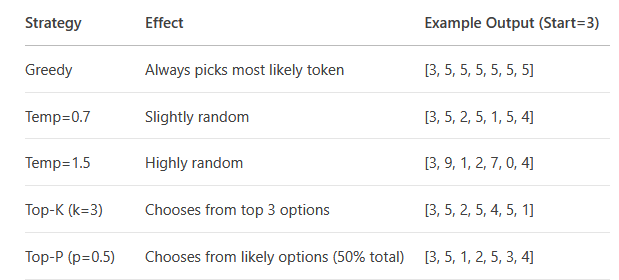


Why This Matters

    Controlled Creativity: Different strategies help balance:

        Accuracy (greedy) vs. diversity (high temp)

        Avoid repetition while maintaining coherence

    Real-World Use:

        Voice assistants use low temp for reliability

        Creative audio generation uses high temp/top-p

Technical Breakdown

    Temperature:

        0.1: Robotic/rigid output

        1.0: Balanced

        2.0: Chaotic

    Top-K/Top-P:

        Limits choices to prevent nonsense tokens

        Top-K: "Only consider 3 best options"

        Top-P: "Consider options until 50% probability mass is covered"

Example Output

Start token: [3]  
Greedy:       [3, 5, 5, 5, 5, 5, 5, 5]  
Temp=1.5:     [3, 9, 1, 2, 7, 0, 4, 1]  
Top-P (0.9):  [3, 5, 2, 1, 5, 3, 4, 2]  

Key Improvement

Previous code only used greedy generation - this adds 9 strategies for controlled sequence creation, mimicking how ChatGPT adjusts response styles.

(Think of it like giving a writer different directive: "Be precise" vs "Brainstorm wildly")